# 03 — Features

This is the single, growing feature-engineering notebook (informed by `02_eda.ipynb`, which runs first). Every new feature gets added here as a new section, reading `data/interim/` inputs from `01_preprocessing.ipynb` and writing one cumulative feature file other notebooks build on.

Built so far: floor area (as of sale date), inflation adjustment, geocoding, `relative_size`, house type, coastal distance.

In [1]:
import sys
sys.path.insert(0, "..")
from src.config import DATA_RAW, DATA_INTERIM, HPI_NAMES
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

joined = pd.read_parquet(DATA_INTERIM / "ppd_epc_joined.parquet")
epc = pd.read_parquet(DATA_INTERIM / "epc_clean.parquet")
print(f"{len(joined):,} joined transactions | {len(epc):,} EPC certificates")
print(joined["district"].value_counts().to_string())


287,930 joined transactions | 641,578 EPC certificates
district
LIVERPOOL    86633
WIRRAL       74085
SEFTON       61089
ST HELENS    37873
KNOWSLEY     28250


## Part A0 — attach each sale's own floor area (as of the sale date)

Notebook 03's join found *which* property each sale matches, but didn't
carry the property's floor area, rooms etc. through — that was done
separately, just for the one-off baseline fit, in notebook 03b. Doing it
properly here so every later feature can build on it.

Same rule as before: a property can have several EPC certificates over
time, so for each sale we take the certificate **current as of that sale
date** (plan Part 5, leakage control #1) — never one issued after, since
that could reflect a renovation the buyer made *after* buying.


In [2]:
epc_sorted = epc.dropna(subset=["UPRN"]).sort_values("inspection_date")
epc_groups = {uprn: grp for uprn, grp in epc_sorted.groupby("UPRN")}

def certificate_as_of(uprn, sale_date):
    candidates = epc_groups.get(uprn)
    if candidates is None:
        return None
    valid = candidates[candidates["inspection_date"] <= sale_date]
    return valid.iloc[-1] if not valid.empty else candidates.iloc[0]

attach_cols = ["total_floor_area", "number_habitable_rooms", "number_heated_rooms",
               "property_type", "built_form", "construction_age_band", "tenure"]

rows = []
for row in joined.dropna(subset=["uprn_final"]).itertuples(index=False):
    cert = certificate_as_of(row.uprn_final, row.date_of_transfer)
    d = {"transaction_id": row.transaction_id}
    if cert is not None:
        d.update({c: cert[c] for c in attach_cols})
    rows.append(d)

epc_at_sale = pd.DataFrame(rows)
joined = joined.merge(epc_at_sale, on="transaction_id", how="left")
print(f"Floor area attached for {joined['total_floor_area'].notna().mean():.1%} of joined sales")


Floor area attached for 87.0% of joined sales


## Part A — inflation adjustment

**In plain terms:** the UK HPI is an official monthly score for how expensive
housing is in an area, published by HM Land Registry/ONS. It's not itself a
price — it's an index number (think of it like a thermometer reading, not a
temperature in a specific room). If the index was 50 when a house sold and
it's 110 today, that area's prices have roughly doubled since then, so we
scale that historic sale price up by 110/50 to say what an equivalent house
would sell for *today*. This puts every sale, regardless of year, on the
same footing before the model ever sees it.


In [3]:
hpi = pd.read_csv(
    DATA_RAW / "hpi" / "uk-hpi-full-2026-05.csv",
    usecols=["Date", "RegionName", "Index"],
)
hpi["Date"] = pd.to_datetime(hpi["Date"], format="%d/%m/%Y")

# One index series per authority. Applying Sefton's price growth to
# Liverpool sales would inject error rather than remove it - these markets
# have not moved at the same rate.
region_to_district = {v: k for k, v in HPI_NAMES.items()}
hpi = hpi[hpi["RegionName"].isin(region_to_district)].copy()
hpi["district"] = hpi["RegionName"].map(region_to_district)
hpi = hpi.sort_values("Date").reset_index(drop=True)

latest_date = hpi["Date"].max()
latest = hpi[hpi["Date"] == latest_date].set_index("district")["Index"]
print(f"Adjusting every sale to {latest_date.date()} prices, per authority:")
print(latest.to_string())


Adjusting every sale to 2026-05-01 prices, per authority:
district
SEFTON       109.8
LIVERPOOL    113.7
KNOWSLEY     107.4
ST HELENS    109.1
WIRRAL       108.0


In [4]:
# Match each sale to its OWN authority's index for that month.
# merge_asof needs both sides sorted by the join key; `by=` keeps the
# authorities from bleeding into each other.
joined = joined.sort_values("date_of_transfer")
hpi_sorted = hpi.sort_values("Date")

joined = pd.merge_asof(
    joined, hpi_sorted[["Date", "Index", "district"]],
    left_on="date_of_transfer", right_on="Date",
    by="district", direction="backward",
)

joined["latest_index"] = joined["district"].map(latest)
joined["price_adjusted"] = joined["price"] * (joined["latest_index"] / joined["Index"])

unmatched = joined["Index"].isna().sum()
print(f"{unmatched:,} sales couldn't be matched to an HPI month (should be ~0)")
joined[["district", "date_of_transfer", "price", "Index", "price_adjusted"]].head()


0 sales couldn't be matched to an HPI month (should be ~0)


,district,date_of_transfer,price,Index,price_adjusted
0,LIVERPOOL,2008-01-01,140000,72.9,218353.909465
1,LIVERPOOL,2008-01-02,175000,72.9,272942.386831
2,SEFTON,2008-01-02,89950,74.7,132215.662651
3,LIVERPOOL,2008-01-02,71000,72.9,110736.625514
4,LIVERPOOL,2008-01-02,109000,72.9,170004.115226


## Check: does the adjustment actually flatten the price-growth trend?

If it worked, median *adjusted* price by year should be roughly flat,
unlike the raw median which climbed from £147,500 to £240,000.


         price  price_adjusted
year                          
2008  125000.0   197079.588150
2009  126000.0   218755.980861
2010  125000.0   212749.017433
2011  124000.0   217096.121417
2012  124950.0   220277.777778
2013  125000.0   224398.544408
2014  129195.0   223392.857143
2015  134000.0   225671.641791
2016  136995.0   222057.268722
2017  143000.0   220291.390728
2018  147000.0   219215.155616
2019  152995.0   222209.530313
2020  163500.0   229258.855586
2021  180000.0   222976.398872
2022  190000.0   216196.550598
2023  194995.0   214637.755102
2024  205000.0   221769.422652
2025  215000.0   222484.115984
2026  215000.0   215490.125560


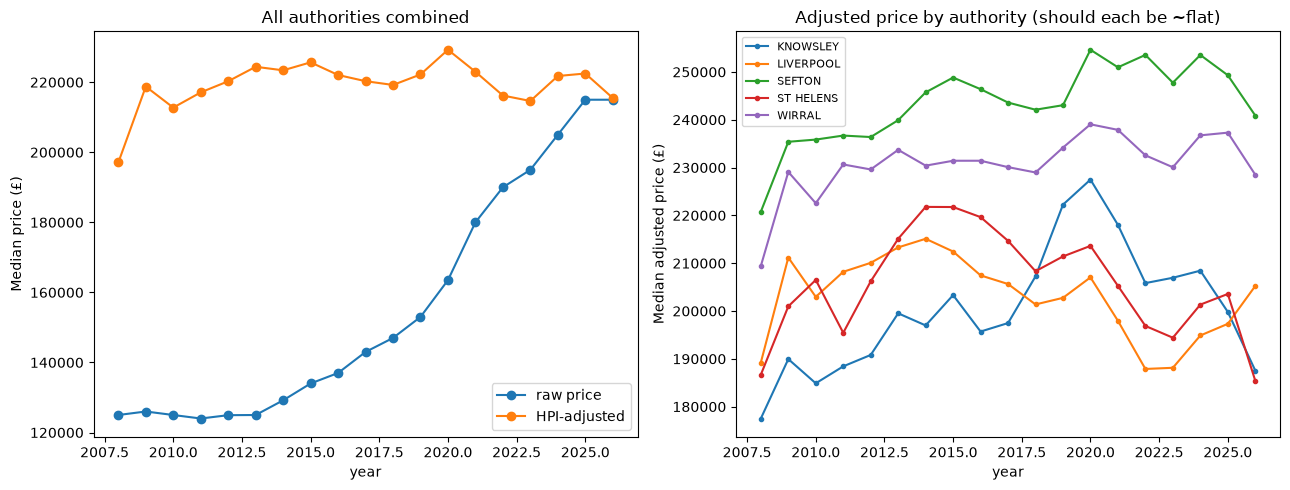

In [5]:
joined["year"] = joined["date_of_transfer"].dt.year
by_year = joined.groupby("year")[["price", "price_adjusted"]].median()
print(by_year)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
by_year["price"].plot(ax=axes[0], marker="o", label="raw price")
by_year["price_adjusted"].plot(ax=axes[0], marker="o", label="HPI-adjusted")
axes[0].set_ylabel("Median price (£)")
axes[0].set_title("All authorities combined")
axes[0].legend()

for district, grp in joined.groupby("district"):
    grp.groupby("year")["price_adjusted"].median().plot(ax=axes[1], marker=".", label=district)
axes[1].set_ylabel("Median adjusted price (£)")
axes[1].set_title("Adjusted price by authority (should each be ~flat)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Part B — geocoding

**In plain terms:** postcodes.io is a free, no-signup lookup that turns a UK
postcode into a latitude/longitude plus some official geography codes (which
statistical small-area it falls in, its deprivation rank, etc). It has a
bulk endpoint that accepts up to 100 postcodes per request, so we batch
through every unique postcode rather than looking each one up individually.

We geocode the postcodes from the **full EPC certificate set** (116,070
rows), not just the 61,344 that matched a sale — `relative_size` needs to
know about nearby houses whether or not they've ever sold.


In [6]:
unique_postcodes = epc["POSTCODE"].dropna().unique().tolist()
print(f"{len(unique_postcodes):,} unique postcodes to geocode")


30,517 unique postcodes to geocode


In [7]:
def geocode_batch(postcodes: list[str]) -> pd.DataFrame:
    resp = requests.post(
        "https://api.postcodes.io/postcodes",
        json={"postcodes": postcodes},
        timeout=30,
    )
    resp.raise_for_status()
    body = resp.json()
    rows = []
    for item in body["result"]:
        pc = item["query"]
        r = item.get("result")
        if r is None:
            continue
        rows.append({
            "postcode": pc,
            "lat": r["latitude"],
            "lon": r["longitude"],
            "lsoa": r["lsoa"],
            "msoa": r["msoa"],
            "admin_ward": r["admin_ward"],
        })
    return pd.DataFrame(rows)

geo_cache = DATA_INTERIM / "postcode_geocodes.parquet"
if geo_cache.exists():
    geocodes = pd.read_parquet(geo_cache)
    print(f"Loaded {len(geocodes):,} cached geocodes")
else:
    batches = [unique_postcodes[i:i+100] for i in range(0, len(unique_postcodes), 100)]
    results = []
    for i, batch in enumerate(batches):
        results.append(geocode_batch(batch))
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{len(batches)} batches done")
    geocodes = pd.concat(results, ignore_index=True)
    geocodes.to_parquet(geo_cache, index=False)
    print(f"Geocoded {len(geocodes):,} / {len(unique_postcodes):,} postcodes ({len(geocodes)/len(unique_postcodes):.1%})")


Loaded 32,843 cached geocodes


## Attach coordinates and save

Both the sale-matched dataset and the full EPC set get coordinates, since
Part A's output feeds the model directly and Part B's fuller set feeds
`relative_size`.


In [8]:
joined_geo = joined.merge(geocodes, left_on="postcode", right_on="postcode", how="left")
epc_geo = epc.merge(geocodes, left_on="POSTCODE", right_on="postcode", how="left")

print(f"Sales with coordinates: {joined_geo['lat'].notna().mean():.1%}")
print(f"EPC certificates with coordinates: {epc_geo['lat'].notna().mean():.1%}")


Sales with coordinates: 99.9%
EPC certificates with coordinates: 99.8%


## Part C — `relative_size`: how big is this house compared to its neighbours?

This is the main idea we're testing (plan Part 2). The original buyer's
report found that on streets where every house is roughly the same size,
floor area alone stops predicting price at all (R² collapsed from 0.88 on
varied streets to 0.076 on a uniform one) — because there's no variation
left for it to explain. `relative_size` reframes the same number: instead
of "this house is 120 m²," it says "this house is 35% bigger than the
average of the 15 nearest properties" — which still carries information
even when every house nearby is a similar size, and means the same 120 m²
is read differently on a street of 80 m² houses vs a street of 150 m² ones.

**How "nearest" is found:** convert latitude/longitude to plain
east/north metres on the **British National Grid** (the coordinate system
British maps and other UK features in this project use), then use a
**KD-tree** — a standard data structure for "find the k closest points"
that's far faster than checking every pair of houses by hand — to pull the
15 nearest properties to each sale, by straight-line distance.

**The neighbour pool is the full EPC set** (116,070 certificates, not just
sold ones), deduplicated to each property's most recent floor area, so a
house that has never sold can still act as a "neighbour" for comparison.


In [9]:
from scipy.spatial import cKDTree
import pyproj

K = 15  # matches sqft_living15 in the reference project

neighbour_pool = epc_geo.dropna(subset=["UPRN", "lat", "lon", "total_floor_area"]).copy()
neighbour_pool = neighbour_pool.sort_values("inspection_date").drop_duplicates(subset=["UPRN"], keep="last")
print(f"{len(neighbour_pool):,} unique properties in the neighbour pool")

# EPSG:4326 = plain lat/lon (what we have); EPSG:27700 = British National Grid,
# metres on a flat plane (what we need for real distances - plan Part 2 flags
# raw lat/lon degrees as "the classic error", same reasoning applies here).
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:27700", always_xy=True)
easting, northing = transformer.transform(neighbour_pool["lon"].values, neighbour_pool["lat"].values)
neighbour_pool = neighbour_pool.assign(easting=easting, northing=northing)

tree = cKDTree(neighbour_pool[["easting", "northing"]].to_numpy())
pool_uprns = neighbour_pool["UPRN"].to_numpy()
pool_areas = neighbour_pool["total_floor_area"].to_numpy()
uprn_to_pool_idx = {u: i for i, u in enumerate(pool_uprns)}


459,605 unique properties in the neighbour pool


In [10]:
def neighbourhood_mean_area(lat, lon, own_uprn, k=K):
    if pd.isna(lat) or pd.isna(lon):
        return np.nan
    e, n = transformer.transform(lon, lat)
    # ask for k+1 in case the property itself is in the pool, then drop it
    dists, idxs = tree.query([e, n], k=k + 1)
    own_idx = uprn_to_pool_idx.get(own_uprn)
    idxs = [i for i in idxs if i != own_idx][:k]
    if not idxs:
        return np.nan
    return pool_areas[idxs].mean()

joined_geo["neighbourhood_mean_area"] = [
    neighbourhood_mean_area(row.lat, row.lon, row.uprn_final)
    for row in joined_geo.itertuples(index=False)
]
joined_geo["relative_size"] = joined_geo["total_floor_area"] / joined_geo["neighbourhood_mean_area"]

print(f"relative_size computed for {joined_geo['relative_size'].notna().mean():.1%} of sales")
print(joined_geo["relative_size"].describe())


relative_size computed for 87.0% of sales
count    250588.000000
mean          1.034702
std           0.319030
min           0.129487
25%           0.877660
50%           0.985169
75%           1.122594
max           9.753989
Name: relative_size, dtype: float64


## Does it correlate with price better than raw floor area?

The real test. If the idea works, `relative_size` should hold up (or do
better) specifically on the streets where raw floor area struggles.


In [11]:
have_both = joined_geo.dropna(subset=["relative_size", "total_floor_area", "price_adjusted"])
log_price = np.log(have_both["price_adjusted"])
print(f"log(price) vs log(floor_area):    corr = {np.corrcoef(np.log(have_both['total_floor_area']), log_price)[0,1]:+.3f}")
print(f"log(price) vs log(relative_size): corr = {np.corrcoef(np.log(have_both['relative_size']), log_price)[0,1]:+.3f}")


log(price) vs log(floor_area):    corr = +0.640
log(price) vs log(relative_size): corr = +0.212


## Save the full feature set


In [12]:
joined_geo.to_parquet(DATA_INTERIM / "ppd_epc_joined_features.parquet", index=False)
epc_geo.to_parquet(DATA_INTERIM / "epc_sefton_geocoded.parquet", index=False)
print("Saved.")


Saved.


---
## House type and coastal distance

In [13]:
import sys
sys.path.insert(0, "..")
from src.config import DATA_RAW, DATA_INTERIM
import pandas as pd
import numpy as np
import geopandas as gpd
import statsmodels.api as sm

df = pd.read_parquet(DATA_INTERIM / "ppd_epc_joined_features.parquet")
print(f"{len(df):,} transactions with features so far")


287,930 transactions with features so far


## Part A — house type

`built_form` is a category (Detached, Semi-Detached, Mid-Terrace, ...), not
a number, so a straight-line model needs it turned into a set of yes/no
columns — e.g. `is_detached` (1 if detached, 0 otherwise) — one per
category. This is called **one-hot encoding**. We drop one category
(terraces, the most common) as the "baseline" that the others are compared
against, which is standard practice and avoids redundant columns.


In [14]:
# Collapse rare sub-categories (Enclosed Mid/End-Terrace) into their plain
# counterparts - EDA showed them behaving similarly and some have very few
# examples, which makes their own dummy coefficient unstable.
built_form_map = {
    "Enclosed Mid-Terrace": "Mid-Terrace",
    "Enclosed End-Terrace": "End-Terrace",
}
df["built_form_clean"] = df["built_form"].replace(built_form_map)

dummies = pd.get_dummies(df["built_form_clean"], prefix="type", drop_first=True, dtype=float)
print("Categories (one dropped as baseline):", dummies.columns.tolist())
df = pd.concat([df, dummies], axis=1)


Categories (one dropped as baseline): ['type_End-Terrace', 'type_Mid-Terrace', 'type_Not Recorded', 'type_Semi-Detached']


### Dwelling type — what the property *is*, not just its shape

`built_form` describes the shape of the **building** (detached,
semi-detached, terraced). It does not say whether the dwelling inside is a
house, a flat, a bungalow or a maisonette — and that turns out to matter
enormously:

| Built form | House | Bungalow | Flat |
|---|---|---|---|
| Detached | £378,635 | £352,748 | **£162,673** |
| Semi-Detached | £237,273 | £230,590 | **£160,000** |

A flat in a detached building was being fed to the model with the same
label as a detached house worth **133% more**. That affects ~29,400 flats
and ~17,000 bungalows — about 15% of rows — and the two errors run in
*opposite* directions, since bungalows sell 8–11% **above** houses of the
same size and shape.

Leasehold is not a substitute for this: only 40.4% of leasehold properties
are flats, and leasehold *houses* (£213,261 median) versus leasehold *flats*
(£160,815) is itself a 33% gap.

This is very likely what produced the measured **+8.5% over-prediction on
sub-£200k properties** — cheap flats being valued as though they were houses.

The data was in the file all along; it simply never reached the feature list.


In [15]:
# EPC's property_type is the dwelling type; Price Paid's is a mix of shape
# and type (D/S/T/F). They agree on "is it a flat" 98.9% of the time, so we
# take the EPC one - it also distinguishes bungalows and maisonettes, which
# Price Paid cannot.
df["dwelling_type"] = df["property_type_y"]

# Park homes are a handful of rows and a different market entirely.
rare = df["dwelling_type"].value_counts()
print(df["dwelling_type"].value_counts(dropna=False).to_string())
df.loc[df["dwelling_type"] == "Park home", "dwelling_type"] = None

print()
print("Median adjusted price by dwelling type:")
print(df.groupby("dwelling_type", observed=True)["price_adjusted"]
        .agg(["size", "median"]).to_string(float_format=lambda v: f"{v:,.0f}"))


dwelling_type
House         206987
NaN            37341
Flat           28433
Bungalow       14092
Maisonette      1077

Median adjusted price by dwelling type:
                 size  median
dwelling_type                
Bungalow        14092 274,927
Flat            28433 161,381
House          206987 221,574
Maisonette       1077 156,316


## Part B — coastal distance

**Why British National Grid, not raw lat/lon.** A degree of longitude
covers a different real-world distance than a degree of latitude (more so
the further from the equator), so measuring "distance" directly in lat/lon
numbers gives a distorted answer. EPSG:27700 (British National Grid) is a
flat-earth projection designed for exactly this — coordinates in it are
plain metres on a grid, the same system British maps use.

**Why beach polygons, not the general coastline.** Sefton's shoreline runs
from Crosby beach into Seaforth container terminal further south. Measuring
to the nearest bit of *any* coastline would score a house backing onto a
working port the same as one facing the beach. Beach polygons are tagged
in OpenStreetMap specifically as `natural=beach` — nobody tags a container
terminal that way, so this measure only ever finds genuine open beach.


In [16]:
osm_path = DATA_RAW / "osm" / "merseyside-latest.osm.pbf"

beaches = gpd.read_file(osm_path, layer="multipolygons", where="natural = 'beach'")
print(f"{len(beaches)} beach polygons found")

marine_lakes = gpd.read_file(osm_path, layer="multipolygons", where="natural = 'water'")
marine_lakes = marine_lakes[marine_lakes["name"].str.contains("Marine Lake", case=False, na=False)]
print(f"{len(marine_lakes)} Marine Lake polygons found")


72 beach polygons found


4 Marine Lake polygons found


In [17]:
BNG = "EPSG:27700"
beaches_bng = beaches.to_crs(BNG)
lakes_bng = marine_lakes.to_crs(BNG)

# One combined shape per feature type - much faster to measure distance to
# a single unified shape than to loop over 72 separate beach polygons.
beach_shape = beaches_bng.union_all()
lake_shape = lakes_bng.union_all()

properties = df.dropna(subset=["lat", "lon"]).copy()
points = gpd.GeoSeries(
    gpd.points_from_xy(properties["lon"], properties["lat"]), crs="EPSG:4326"
).to_crs(BNG)

properties["dist_to_beach_m"] = points.distance(beach_shape).values
properties["dist_to_marine_lake_m"] = points.distance(lake_shape).values

print(properties[["dist_to_beach_m", "dist_to_marine_lake_m"]].describe())


       dist_to_beach_m  dist_to_marine_lake_m
count    287718.000000          287718.000000
mean       6533.751880            9145.660862
std        6178.926051            6189.868068
min          28.470082              27.136908
25%        2178.182894            4597.616121
50%        4272.028150            8014.810623
75%        8384.327235           12579.647938
max       27399.043289           28623.958820


## Sanity checks

1. No property should show as essentially on top of the beach *and* be in
   Bootle/Seaforth (postcodes L20/L21, where the docks are) — that would
   mean the docks were accidentally being scored as beach.
2. Beach and Marine Lake distance were flagged in the plan as likely
   redundant (~200 m apart in reality) — check the correlation between them
   before deciding whether to keep both.


In [18]:
dock_area = properties[properties["postcode"].str.startswith(("L20", "L21"))]
print(f"Closest a Bootle/Seaforth (L20/L21) property gets to 'beach': "
      f"{dock_area['dist_to_beach_m'].min():.0f} m "
      f"(should be a real distance, not ~0)")

corr = properties[["dist_to_beach_m", "dist_to_marine_lake_m"]].corr().iloc[0, 1]
print(f"\nCorrelation between beach distance and Marine Lake distance: {corr:+.3f}")
print("Keeping both if clearly separate, dropping one if this is above ~0.9 as expected.")


Closest a Bootle/Seaforth (L20/L21) property gets to 'beach': 791 m (should be a real distance, not ~0)

Correlation between beach distance and Marine Lake distance: +0.885
Keeping both if clearly separate, dropping one if this is above ~0.9 as expected.


## Does coastal distance actually correlate with price?


In [19]:
have_price = properties.dropna(subset=["price_adjusted"])
log_price = np.log(have_price["price_adjusted"])
corr_beach = np.corrcoef(have_price["dist_to_beach_m"], log_price)[0, 1]
print(f"log(price) vs distance to beach: corr = {corr_beach:+.3f}  "
      f"(negative expected - further from the beach, cheaper)")


log(price) vs distance to beach: corr = -0.084  (negative expected - further from the beach, cheaper)


## Save the full feature set

In [20]:
properties.to_parquet(DATA_INTERIM / "features.parquet", index=False)
print(f"Saved {len(properties):,} rows, {properties.shape[1]} columns to features.parquet")

Saved 287,718 rows, 55 columns to features.parquet


---
# Condition — the biggest missing variable

Everything above describes a house's *size, type and location*. None of it
describes **what the place is actually like inside**. A refurbished house
and one with damp and a 1970s kitchen look identical to the model — yet
that difference is worth £20–30k on a £300k property, which is most of the
error we're still carrying.

No free UK dataset records house condition. But three proxies are
constructible from what we already have, and the first is far stronger than
expected.


## 1. What the house last sold for  *(#4)*

If a property sold before, that price — restated in today's money — carries
almost everything the model can't otherwise see: condition, aspect, plot,
garden, which end of the street it's on. A real buyer already priced all of
it.

| | correlation with price |
|---|---|
| **Previous sale price (HPI-adjusted)** | **+0.890** |
| Floor area | +0.673 |

Used *by itself* as a prediction, with no model at all, it lands within
11.0% — roughly matching our entire tuned model. Available for **46.6% of
recent sales**.

⚠️ **Sharpest leakage risk in the project**, and the assertion below has now
caught two genuine bugs:

1. **Same-day duplicates** — Land Registry recording one sale twice under
   different transaction IDs. Fixed in `01_preprocessing.ipynb`.
2. **Shared UPRNs** — the address matcher's fuzzy fallback collapses
   distinct flats in one building onto a single UPRN. FLAT 1–4 at 17 Rocky
   Lane all share UPRN 38128640, so grouping by UPRN would treat *a
   different flat's* sale as this flat's previous sale.

So sale history is grouped by **`(postcode, paon, saon)`** — Price Paid's own
identifier for the actual dwelling — rather than by UPRN. We also record
`uprn_n_addresses`: where a UPRN covers several dwellings, the EPC attached
to the sale describes the *building*, not necessarily this flat, which is
worth both a model feature and a confidence-flag warning later.


In [21]:
# Price Paid's own identifier for a specific dwelling. Used instead of UPRN
# because the matcher's fuzzy fallback can collapse several flats onto one
# UPRN - see the note above.
properties["property_key"] = (
    properties["postcode"].fillna("") + "|" +
    properties["paon"].fillna("") + "|" +
    properties["saon"].fillna("")
)

# How many distinct dwellings share each UPRN? >1 means the EPC describes
# the building rather than this specific flat.
uprn_spread = (properties.dropna(subset=["uprn_final"])
               .groupby("uprn_final")["property_key"].nunique()
               .rename("uprn_n_addresses"))
properties = properties.merge(uprn_spread, on="uprn_final", how="left")
shared = properties["uprn_n_addresses"] > 1
print(f"{shared.sum():,} sales ({shared.mean():.1%}) sit on a UPRN shared by "
      f"more than one dwelling - their EPC describes the building, not the flat")

# Defence in depth: dedupe on (dwelling, date) at the point of use, so the
# sale-history feature is correct regardless of what upstream produced.
before = len(properties)
properties = properties.sort_values("date_of_transfer").drop_duplicates(
    subset=["property_key", "date_of_transfer"], keep="first"
).reset_index(drop=True)
if before != len(properties):
    print(f"Dropped {before - len(properties):,} residual same-day duplicate sales")

# Previous sale of the SAME DWELLING. Sorted by date first, then shift(1)
# within each property - so this can only ever look backwards.
g = properties.groupby("property_key")
properties["prev_price_adj"] = g["price_adjusted"].shift(1)
properties["prev_sale_date"] = g["date_of_transfer"].shift(1)
properties["prev_sale_count"] = g.cumcount()

properties["years_since_prev_sale"] = (
    (properties["date_of_transfer"] - properties["prev_sale_date"]).dt.days / 365.25
)
properties["log_prev_price_adj"] = np.log(properties["prev_price_adj"])

have = properties["prev_price_adj"].notna()
print(f"{have.sum():,} of {len(properties):,} sales have a prior sale ({have.mean():.1%})")

bad = (properties["prev_sale_date"] >= properties["date_of_transfer"]).sum()
assert bad == 0, f"LEAKAGE: {bad:,} rows use a previous sale dated on/after the target sale"
print("Leakage check passed: every previous sale strictly predates its target sale.")


2,968 sales (1.0%) sit on a UPRN shared by more than one dwelling - their EPC describes the building, not the flat


68,793 of 287,718 sales have a prior sale (23.9%)
Leakage check passed: every previous sale strictly predates its target sale.


## 2. Renovation detection  *(#6)*

Direct, *observed* evidence that work was done — by comparing the EPC
certificate current at the **previous sale** against the one current
**now**:

- **floor area increased** → an extension was physically built
- **`extension_count` rose** → the same, recorded explicitly
- **SAP score jumped** → insulation, new boiler, new windows
- **glazing upgraded** → single → double, or pre-2002 → post-2002
- **heating upgraded** → room heaters → central heating

This is the measurable form of the extension intuition: rather than
guessing that a recent extension implies better condition, we check whether
the certificate actually changed.

Both lookups use `merge_asof`, which matches each sale to the most recent
certificate *at or before* a given date — vectorised, and backward-looking
by construction.


In [22]:
import duckdb
from src.config import EPC_CSV

RENO_COLS = ["uprn", "inspection_date", "total_floor_area",
             "current_energy_efficiency", "extension_count",
             "glazed_type", "mainheat_description"]

con = duckdb.connect()
epc_reno = con.execute(f"""
    SELECT {', '.join(RENO_COLS)}
    FROM read_csv('{EPC_CSV.as_posix()}', header=true, all_varchar=true, sample_size=-1)
    WHERE uprn IS NOT NULL
""").df()

epc_reno["uprn"] = pd.to_numeric(epc_reno["uprn"], errors="coerce")
epc_reno["inspection_date"] = pd.to_datetime(epc_reno["inspection_date"], errors="coerce")
for c in ["total_floor_area", "current_energy_efficiency", "extension_count"]:
    epc_reno[c] = pd.to_numeric(epc_reno[c], errors="coerce")

GLAZE_RANK = {
    "single glazing": 0, "secondary glazing": 1,
    "double glazing installed before 2002": 2,
    "double glazing, unknown install date": 3,
    "double glazing installed during or after 2002": 4,
    "triple glazing": 5,
}
epc_reno["glazing_score"] = epc_reno["glazed_type"].str.lower().map(GLAZE_RANK)
epc_reno["has_central_heating"] = (
    ~epc_reno["mainheat_description"].fillna("").str.contains("room heater", case=False)
).astype(float)

# merge_asof requires identical key dtypes on both sides, and
# uprn_final is float (it carries missing values), so match it.
epc_reno["uprn"] = epc_reno["uprn"].astype("float64")

epc_reno = (epc_reno.dropna(subset=["uprn", "inspection_date"])
                    .sort_values("inspection_date")
                    .reset_index(drop=True))
print(f"{len(epc_reno):,} certificates available for the before/after comparison")


681,770 certificates available for the before/after comparison


In [23]:
SNAP = ["total_floor_area", "current_energy_efficiency", "extension_count",
        "glazing_score", "has_central_heating"]

def certificate_as_of(sales, date_col, suffix):
    """Most recent certificate at or before `date_col`, per property."""
    left = (sales.dropna(subset=[date_col, "uprn_final"])
                 .sort_values(date_col)[["transaction_id", "uprn_final", date_col]])
    out = pd.merge_asof(
        left, epc_reno[["uprn", "inspection_date"] + SNAP],
        left_on=date_col, right_on="inspection_date",
        left_by="uprn_final", right_by="uprn",
        direction="backward",
    )
    keep = ["transaction_id", "inspection_date"] + SNAP
    return out[keep].rename(columns={c: f"{c}{suffix}" for c in ["inspection_date"] + SNAP})

now  = certificate_as_of(properties, "date_of_transfer", "_now")
prev = certificate_as_of(properties, "prev_sale_date",   "_prev")

properties = properties.merge(now,  on="transaction_id", how="left")
properties = properties.merge(prev, on="transaction_id", how="left")

# The certificate used must never postdate the sale it describes.
late = (properties["inspection_date_now"] > properties["date_of_transfer"]).sum()
assert late == 0, f"LEAKAGE: {late:,} sales matched to a certificate issued after the sale"
print("Leakage check passed: no certificate postdates the sale it describes.")

properties["area_change"]      = properties["total_floor_area_now"] - properties["total_floor_area_prev"]
properties["sap_change"]       = properties["current_energy_efficiency_now"] - properties["current_energy_efficiency_prev"]
properties["extension_change"] = properties["extension_count_now"] - properties["extension_count_prev"]
properties["glazing_change"]   = properties["glazing_score_now"] - properties["glazing_score_prev"]
properties["heating_upgraded"] = (
    (properties["has_central_heating_now"] == 1) & (properties["has_central_heating_prev"] == 0)
).astype(float)

comparable = properties["total_floor_area_prev"].notna()
print(f"\n{comparable.sum():,} sales have certificates at BOTH dates ({comparable.mean():.1%})")
print("\nEvidence of work between the two sales:")
print(f"  floor area increased >5 m2 : {(properties['area_change'] > 5).sum():,}")
print(f"  extension_count rose       : {(properties['extension_change'] > 0).sum():,}")
print(f"  SAP score rose >10 points  : {(properties['sap_change'] > 10).sum():,}")
print(f"  glazing upgraded           : {(properties['glazing_change'] > 0).sum():,}")
print(f"  heating upgraded           : {(properties['heating_upgraded'] == 1).sum():,}")


Leakage check passed: no certificate postdates the sale it describes.

36,741 sales have certificates at BOTH dates (12.8%)

Evidence of work between the two sales:
  floor area increased >5 m2 : 2,639
  extension_count rose       : 2,115
  SAP score rose >10 points  : 3,590
  glazing upgraded           : 3,194
  heating upgraded           : 511


## 3. Flip signals  *(#7)*

Confirmed in our own data — properties resold quickly gain far more than
the market:

| Holding period | Median gain | **Annualised** |
|---|---|---|
| Under 1 year | +13.3% | **+23.9%** |
| 10+ years | +48.7% | +3.2% |

24% annualised against 3.2% is not the market moving; it is work being done
and sold on.

⚠️ **We cannot use the realised gain.** It requires the current sale price —
the thing being predicted. What we legitimately know when valuing a house
today is: how long the current owner has held it, what they paid, and
whether a new certificate appeared showing improvement. That last one is the
direct evidence, and comes from §2 above.


In [24]:
properties["short_hold"] = (properties["years_since_prev_sale"] < 2).astype(float)
properties.loc[properties["years_since_prev_sale"].isna(), "short_hold"] = np.nan

# "Work was done since the current owner bought it" - any of the observable
# improvements, not the price gain.
properties["work_done_since_prev"] = (
    (properties["area_change"] > 5)
    | (properties["extension_change"] > 0)
    | (properties["sap_change"] > 10)
    | (properties["glazing_change"] > 0)
    | (properties["heating_upgraded"] == 1)
).astype(float)
properties.loc[properties["total_floor_area_prev"].isna(), "work_done_since_prev"] = np.nan

# Bought recently AND visibly improved - the flip signature.
properties["likely_flip"] = (
    (properties["short_hold"] == 1) & (properties["work_done_since_prev"] == 1)
).astype(float)
properties.loc[properties["short_hold"].isna(), "likely_flip"] = np.nan

n = properties["likely_flip"].notna().sum()
print(f"Of {n:,} sales with a prior sale to compare against:")
print(f"  short hold (<2 yrs):        {(properties['likely_flip'].notna() & (properties['short_hold']==1)).sum():,}")
print(f"  visible work done since:    {(properties['work_done_since_prev']==1).sum():,}")
print(f"  BOTH - likely flip:         {(properties['likely_flip']==1).sum():,}")


Of 68,793 sales with a prior sale to compare against:
  short hold (<2 yrs):        9,879
  visible work done since:    6,510
  BOTH - likely flip:         878


## 4. Local market level  *(#10)*

What comparable homes nearby have recently sold for, per square metre. This
was in the original plan and never got built — the model has been inferring
location value from raw latitude/longitude alone, which trees handle only
crudely.

Computed per **postcode sector** (e.g. `L23 1` — finer than a district,
coarse enough to have enough sales to be stable) over the **previous four
quarters**, with the current quarter excluded so no concurrent sale can leak
in.


In [25]:
properties["pc_sector"] = (
    properties["postcode"].str.split(" ").str[0] + " " +
    properties["postcode"].str.split(" ").str[1].str[0]
)
properties["quarter"] = properties["date_of_transfer"].dt.to_period("Q")
properties["price_per_sqm"] = properties["price_adjusted"] / properties["total_floor_area"]

sq = (properties.dropna(subset=["price_per_sqm"])
      .groupby(["pc_sector", "quarter"])["price_per_sqm"]
      .agg(["median", "size"]).reset_index()
      .rename(columns={"median": "sector_ppsqm", "size": "sector_n"}))

# 4-quarter trailing average, SHIFTED so the current quarter is excluded.
# Without the shift this would include sales concurrent with the target.
sq = sq.sort_values(["pc_sector", "quarter"])
sq["local_ppsqm"] = (sq.groupby("pc_sector")["sector_ppsqm"]
                       .transform(lambda s: s.rolling(4, min_periods=1).mean().shift(1)))
sq["local_sales_count"] = (sq.groupby("pc_sector")["sector_n"]
                             .transform(lambda s: s.rolling(4, min_periods=1).sum().shift(1)))

properties = properties.merge(
    sq[["pc_sector", "quarter", "local_ppsqm", "local_sales_count"]],
    on=["pc_sector", "quarter"], how="left")

print(f"local_ppsqm populated for {properties['local_ppsqm'].notna().mean():.1%} of sales")
print(f"median local sales in the prior year: {properties['local_sales_count'].median():.0f}")


local_ppsqm populated for 97.9% of sales
median local sales in the prior year: 38


---
# Amenity distances

All computed the same way as the coastal features: reproject to **British
National Grid (EPSG:27700)** so distances come out in metres, then nearest-
feature distance. Computing in raw lat/lon degrees is the classic error — a
degree of longitude is not a degree of latitude.

Everything here except schools comes from the OSM extract already on disk.
That file is `merseyside-latest.osm.pbf`, which is *exactly* the five
authorities now in scope — West Lancashire was dropped precisely so the map
and the data cover the same ground.


## Rail stations  *(#14)*

Nationwide, controlling for property type and bedrooms, measures a **4.6–4.9%
premium** for a home 500 m from a station versus 1,500 m, in Greater
Manchester and Glasgow — Merseyside should sit in that range.

This was parked earlier on the grounds that "every Crosby property is
400–900 m from a Merseyrail station so it barely varies". That reasoning was
based on Sefton-only data; across five authorities including St Helens and
Knowsley, station access varies a great deal, so the objection no longer
holds.


In [26]:
BNG = "EPSG:27700"
osm_path = DATA_RAW / "osm" / "merseyside-latest.osm.pbf"

# Property points, projected once and reused for every distance below.
pts = gpd.GeoSeries(
    gpd.points_from_xy(properties["lon"], properties["lat"]), crs="EPSG:4326"
).to_crs(BNG)

# In an OSM .pbf the points layer exposes only a few tags as real columns
# (name, highway, place, ...); everything else - including railway - is
# packed into an other_tags string, so it cannot be filtered in SQL.
# multipolygons is different: leisure and natural ARE columns there, which
# is why the beach query below works as written.
stations = gpd.read_file(osm_path, layer="points")
tags = stations["other_tags"].fillna("")
stations = stations[tags.str.contains(r'"railway"=>"(station|halt)"', regex=True)]
print(f"{len(stations)} rail stations/halts found")

station_shape = stations.to_crs(BNG).union_all()
properties["dist_to_station_m"] = pts.distance(station_shape).values
print(properties["dist_to_station_m"].describe().to_string())


C:\Users\jrbah\AppData\Local\Temp\ipykernel_15396\1936541550.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  stations = stations[tags.str.contains(r'"railway"=>"(station|halt)"', regex=True)]


87 rail stations/halts found


count    287718.000000
mean       1217.889386
std         794.040460
min          27.628035
25%         621.347801
50%        1013.628869
75%        1660.885516
max        4429.839838


## Parks and greenspace  *(#15)*

Standard hedonic feature. Includes formal parks and recreation grounds —
`leisure=park` alone misses a lot of municipal greenspace.


In [27]:
parks = gpd.read_file(osm_path, layer="multipolygons",
                      where="leisure IN ('park', 'recreation_ground') OR landuse = 'recreation_ground'")
print(f"{len(parks)} parks / recreation grounds found")

park_shape = parks.to_crs(BNG).union_all()
properties["dist_to_park_m"] = pts.distance(park_shape).values
print(properties["dist_to_park_m"].describe().to_string())


757 parks / recreation grounds found


count    287718.000000
mean        281.976053
std         227.035365
min           0.000000
25%         124.391629
50%         231.120757
75%         378.516315
max        2881.154893


## Schools  *(#17)*

**One metric: distance to the nearest good school.**

The evidence is strong but **conditional** — roughly **10–14.5%** premium
near an Outstanding primary, yet **~1.5% per Ofsted grade in the least
deprived areas and approximately zero in the poorest**. School quality only
capitalises where buyers compete on it, which is exactly the interaction a
tree exploits and a linear model averages into nothing.

**Two files, joined on URN**, because GIAS and Ofsted publish separately:
GIAS gives locations (135 columns in, 7 out — filtered to *open*, mainstream
*primary/secondary*, with real coordinates, inside a generous bounding box
since a school over the county line can still be the nearest). Ofsted gives
the grades.

### Grading is mid-transition, so the score has a three-tier fallback

Ofsted replaced single-word judgements with report cards in November 2025,
and inspects on a multi-year cycle — so no single column covers most
schools. Taking the best available evidence per school, in order:

| Tier | Source | Merseyside schools |
|---|---|---|
| 1 | New report card (2025+) | 67 |
| 2 | Legacy graded inspection | 223 |
| 3 | **Ungraded (Section 8) outcome** | **128** |
| — | genuinely unknown | 76 |

Tier 3 is the one that matters. Section 8 visits don't issue a full grade,
but they do state whether a school has held its standard — *"School remains
Good"* (101 schools), *"Standards maintained"* (20), *"School remains
Outstanding"* (3). That is the previous rating, carried forward, and it
lifts coverage from **56.2% to 83.7%**.

Most of the residual 76 are explained rather than missing: **21 opened in
2024–25**, so they are new academies that genuinely have not been inspected.

⚠️ The legacy grade is stored **inverted** (1 = Outstanding, 4 = Inadequate)
— an easy way to get this exactly backwards.

⚠️ **Catchment matters more than distance.** Being 200 m from an outstanding
school is worth nothing outside its catchment. Distance is a proxy — though
it is also what agents advertise.


In [28]:
gias_path   = DATA_RAW / "schools" / "gias_establishments.csv"
ofsted_path = DATA_RAW / "schools" / "ofsted_latest.csv"

if not (gias_path.exists() and ofsted_path.exists()):
    print("School files missing - feature skipped, everything else still runs.")
    properties["dist_to_good_school_m"] = np.nan
else:
    # --- GIAS: locations. 135 columns in, 7 out. ---
    GIAS_COLS = ["URN", "EstablishmentName", "EstablishmentStatus (name)",
                 "PhaseOfEducation (name)", "Easting", "Northing", "LA (name)"]
    gias = pd.read_csv(gias_path, encoding="latin-1", low_memory=False, usecols=GIAS_COLS)

    gias = gias[gias["EstablishmentStatus (name)"] == "Open"]
    gias = gias.dropna(subset=["Easting", "Northing"])
    gias = gias[(gias["Easting"] > 0) & (gias["Northing"] > 0)]
    gias = gias[gias["PhaseOfEducation (name)"].isin(
        ["Primary", "Secondary", "Middle deemed primary",
         "Middle deemed secondary", "All-through"])]

    # Generous bounding box - a school just over the county line can still
    # be the nearest one to a property near the edge.
    pad = 10_000  # metres
    gias = gias[gias["Easting"].between(pts.x.min() - pad, pts.x.max() + pad)
                & gias["Northing"].between(pts.y.min() - pad, pts.y.max() + pad)]
    print(f"{len(gias):,} open mainstream primary/secondary schools in range")

    # --- Ofsted: one score, three-tier fallback ---
    ofsted = pd.read_csv(ofsted_path, encoding="latin-1", low_memory=False)

    # Tier 1: new report card (2025+). Average the three headline judgements.
    NEW = {"Exceptional": 4, "Strong standard": 4, "Expected standard": 3,
           "Needs attention": 2, "Urgent improvement": 0}
    card = ofsted[["Curriculum and teaching", "Achievement", "Leadership and governance"]]
    tier1 = card.apply(lambda s: s.map(NEW)).mean(axis=1)

    # Tier 2: legacy graded inspection. NOTE the scale is INVERTED.
    LEGACY = {1: 4, 2: 3, 3: 2, 4: 0}
    tier2 = pd.to_numeric(ofsted["Latest OEIF overall effectiveness"], errors="coerce").map(LEGACY)

    # Tier 3: ungraded (Section 8) outcome - the previous rating carried forward.
    UNGRADED = {
        "School remains Outstanding": 4,
        "School remains Outstanding (Concerns) - S5 Next": 3,
        "School remains Good": 3,
        "Standards maintained": 3,
        "Improved significantly": 3,
        "Standards declined": 2,
        "School no longer Outstanding": 3,
        "School no longer Good": 2,
    }
    tier3 = ofsted["Ungraded inspection overall outcome"].map(UNGRADED)

    ofsted["ofsted_score"] = tier1.combine_first(tier2).combine_first(tier3)

    schools = gias.merge(ofsted[["URN", "ofsted_score"]], on="URN", how="left")
    cov = schools["ofsted_score"].notna()
    print(f"  grade available for {cov.sum():,} ({cov.mean():.1%}) after the three-tier fallback")

    # --- the single feature ---
    sch_pts = gpd.GeoSeries(
        gpd.points_from_xy(schools["Easting"], schools["Northing"]), crs=BNG)
    good = (schools["ofsted_score"] >= 3).fillna(False)
    print(f"  {good.sum():,} rated Good/Outstanding or equivalent")

    properties["dist_to_good_school_m"] = pts.distance(sch_pts[good.values].union_all()).values
    print()
    print(properties["dist_to_good_school_m"].describe().to_string(float_format=lambda v: f"{v:,.0f}"))


1,108 open mainstream primary/secondary schools in range


  grade available for 955 (86.2%) after the three-tier fallback
  850 rated Good/Outstanding or equivalent



count   287,718
mean        505
std         307
min           2
25%         291
50%         447
75%         643
max       2,941


## Save the full feature set


In [29]:
properties.to_parquet(DATA_INTERIM / "features.parquet", index=False)
print(f"Saved {len(properties):,} rows, {properties.shape[1]} columns to features.parquet")


Saved 287,718 rows, 90 columns to features.parquet
